In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
load_iris?

Signature: load_iris(*, return_X_y=False, as_frame=False)
Docstring:
Load and return the iris dataset (classification).

The iris dataset is a classic and very easy multi-class classification dataset.

=================   ==============
Classes                          3
Samples per class               50
Samples total                  150
Dimensionality                   4
Features            real, positive
=================   ==============

Read more in the :ref:`User Guide <iris_dataset>`.

.. versionchanged:: 0.20
    Fixed two wrong data points according to Fisher's paper.
    The new version is the same as in R, but not as in the UCI
    Machine Learning Repository.

Parameters
----------
return_X_y : bool, default=False
    If True, returns ``(data, target)`` instead of a Bunch object. See
    below for more information about the `data` and `target` objects.

    .. versionadded:: 0.18

as_frame : bool, default=False
    If True, the data is a pandas DataFrame including columns

In [3]:
iris = load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [4]:
#Leer el dataset
data_df = pd.DataFrame(iris.data, columns=iris.feature_names)
data_df["target"] = iris.target

#Visualizamos las primeras cinco filas
data_df.head(5)

#Visualizamos las últimas cinco filas
#data_df.tail(5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [5]:
#Seleccionar columnas
columns = ["sepal length (cm)", "petal length (cm)", "target"]
data_df = data_df[columns]

#Filtrar las clases a utilizar
data_df = data_df[data_df["target"].isin([0,1])]

data_df.tail(5)

,sepal length (cm),petal length (cm),target
95,5.7,4.2,1
96,5.7,4.2,1
97,6.2,4.3,1
98,5.1,3.0,1
99,5.7,4.1,1


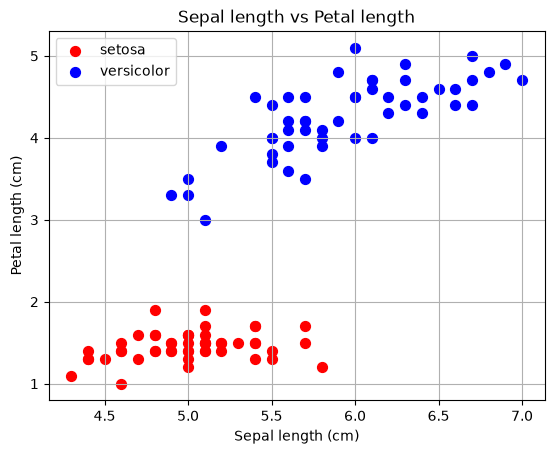

In [6]:
#Visualizar datos
plt.figure()

#Datos de iris setosa
setosa_data = data_df[data_df["target"] == 0]

#Datos de iris versicolor
versicolor_data = data_df[data_df["target"] == 1]

#Graficar los datos
plt.scatter(setosa_data["sepal length (cm)"], setosa_data["petal length (cm)"], label="setosa", color="red", s=50)
plt.scatter(versicolor_data["sepal length (cm)"], versicolor_data["petal length (cm)"], label="versicolor", color="blue", s=50)

plt.title("Sepal length vs Petal length")
plt.xlabel('Sepal length (cm)')
plt.ylabel('Petal length (cm)')
plt.grid()
plt.legend()
plt.show()



In [7]:
X = data_df[["sepal length (cm)", "petal length (cm)"]].values
#print(X)

y = data_df["target"].values 
print(y)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [8]:
#Dividir datos para entrenamiento y prueba
#train_test_split(X, y, test_size=0.2)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
y_train

array([1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1])

In [9]:
#Inicializar y entrenar el Perceptron
perceptron = Perceptron(max_iter=10, eta0=0.05)
perceptron.fit(X_train, y_train)

,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",10
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",0.05
,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",0


In [10]:
#Obtener pesos y sesgo
pesos = perceptron.coef_[0]
sesgo = perceptron.intercept_[0]
print(f'Pesos: {pesos}')
print(f'Sesgo: {sesgo}')

Pesos: [-0.185  0.485]
Sesgo: -0.1


In [15]:
#Predecir los datos del conjunto de prueba
y = perceptron.predict(X_test)
print(y)
print(y_test)

print(perceptron.predict(np.array([6.2, 4.3]).reshape(1, -1)))

[0 1 1 1 0 1 0 1 0 1 1 0 1 0 1 1 1 0 0 1]
[0 1 1 1 0 1 0 1 0 1 1 0 1 0 1 1 1 0 0 1]
[1]


In [12]:
#Calcular exactitud del modelo
accuracy = accuracy_score(y, y_test)
print(f'Exactitud del perceptron: {accuracy:.2f}')

Exactitud del perceptron: 1.00


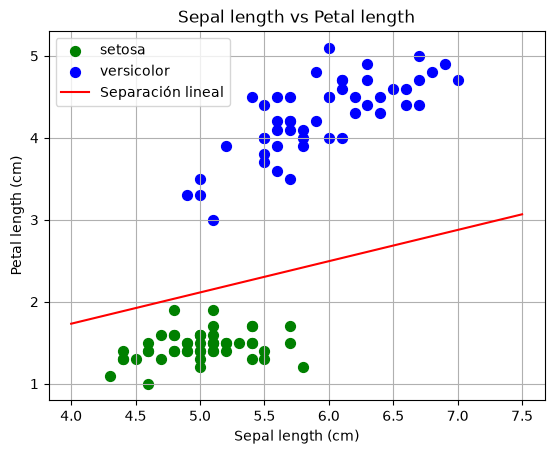

In [14]:
#Visualizar datos
plt.figure()

#Datos de iris setosa
setosa_data = data_df[data_df["target"] == 0]

#Datos de iris versicolor
versicolor_data = data_df[data_df["target"] == 1]

#Graficar los datos
plt.scatter(setosa_data["sepal length (cm)"], setosa_data["petal length (cm)"], label="setosa", color="green", s=50)
plt.scatter(versicolor_data["sepal length (cm)"], versicolor_data["petal length (cm)"], label="versicolor", color="blue", s=50)

x_values = np.linspace(4, 7.5, 100)
y_values = (-pesos[0] / pesos[1]) * x_values - sesgo / pesos[1]
plt.plot(x_values, y_values, '-r', label='Separación lineal')

plt.title("Sepal length vs Petal length")
plt.xlabel('Sepal length (cm)')
plt.ylabel('Petal length (cm)')
plt.grid()
plt.legend()
plt.show()
